#### Based upon: [Real VS Fake face CNN model](https://www.kaggle.com/code/abdalrhmanmorsi/real-vs-fake-face-cnn-model)

In [1]:
import os
import glob
import numpy as np
import cv2
from PIL import Image
import pandas as pd
from collections import Counter

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from torchvision import datasets, transforms, models

In [2]:
DATA_DIR = 'data'
NORMALIZED_DATA = './normalizedData/'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_DIR_NAMES = ['wiki', 'inpainting', 'insight', 'text2img']
REAL_IMG_DIR = 'wiki'

# ! Bath should change considering the memory of the GPU
BATCH_SIZE = 64

In [3]:
# Check if CUDA is available with PyTorch
print("Checking for available hardware...")
print('Using DEVICE:', DEVICE)
if DEVICE.type == 'cuda':
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU found, using CPU instead")

Checking for available hardware...
Using DEVICE: cuda
CUDA Device: NVIDIA GeForce RTX 4070 Ti SUPER
CUDA Memory: 17.17 GB


In [4]:
# Loading of the images
def load__images(data_dir):
    dataset = {"image_path":[], "img_status":[]}

    print(f"Loading and preprocessing images from {data_dir}...")
    for main_folder in IMG_DIR_NAMES:
        main_folder_path = os.path.join(data_dir, main_folder)
        print(f"Processing directory {main_folder}...")
        for subfolder_name in os.listdir(main_folder_path):
            subfolder_path = os.path.join(main_folder_path, subfolder_name)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.endswith('.jpg'):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            dataset["image_path"].append(img_path)
                            dataset["img_status"].append("real" if main_folder == REAL_IMG_DIR else "fake")
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
                    else:
                        print(f"Skipping non jpg file: {filename}")

    dataset = pd.DataFrame(dataset)
    return dataset

In [5]:
dataset = load__images(DATA_DIR)
dataset

Loading and preprocessing images from data...
Processing directory wiki...
Processing directory inpainting...
Processing directory insight...
Processing directory text2img...


,image_path,img_status
0,data\wiki\00\10049200_1891-09-16_1958.jpg,real
1,data\wiki\00\10110600_1985-09-17_2012.jpg,real
2,data\wiki\00\10126400_1964-07-07_2010.jpg,real
3,data\wiki\00\102100_1970-10-09_2008.jpg,real
4,data\wiki\00\10525500_1916-02-14_1951.jpg,real
...,...,...
119995,data\text2img\99\9611799_1955-03-22_2012.jpg,fake
119996,data\text2img\99\9799_1960-06-22_2012.jpg,fake
119997,data\text2img\99\9811999_1953-06-14_2004.jpg,fake
119998,data\text2img\99\9863599_1948-08-13_1963.jpg,fake


In [6]:
dataset.value_counts("img_status")

img_status
fake    90000
real    30000
Name: count, dtype: int64

Real: 30000,
Fake: 90000



C:\Users\Cristiano\AppData\Local\Temp\ipykernel_1620\3809996067.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  real = dataset.value_counts("img_status")[1]
C:\Users\Cristiano\AppData\Local\Temp\ipykernel_1620\3809996067.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fake = dataset.value_counts("img_status")[0]


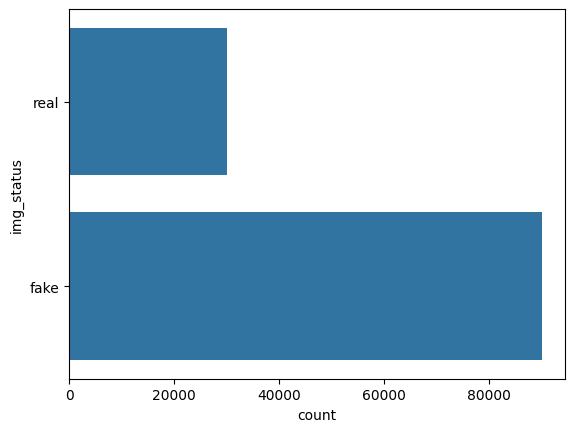

In [7]:
real = dataset.value_counts("img_status")[1]
fake = dataset.value_counts("img_status")[0]

print(f"Real: {real},\nFake: {fake}\n")
sns.countplot(dataset["img_status"])
plt.show()

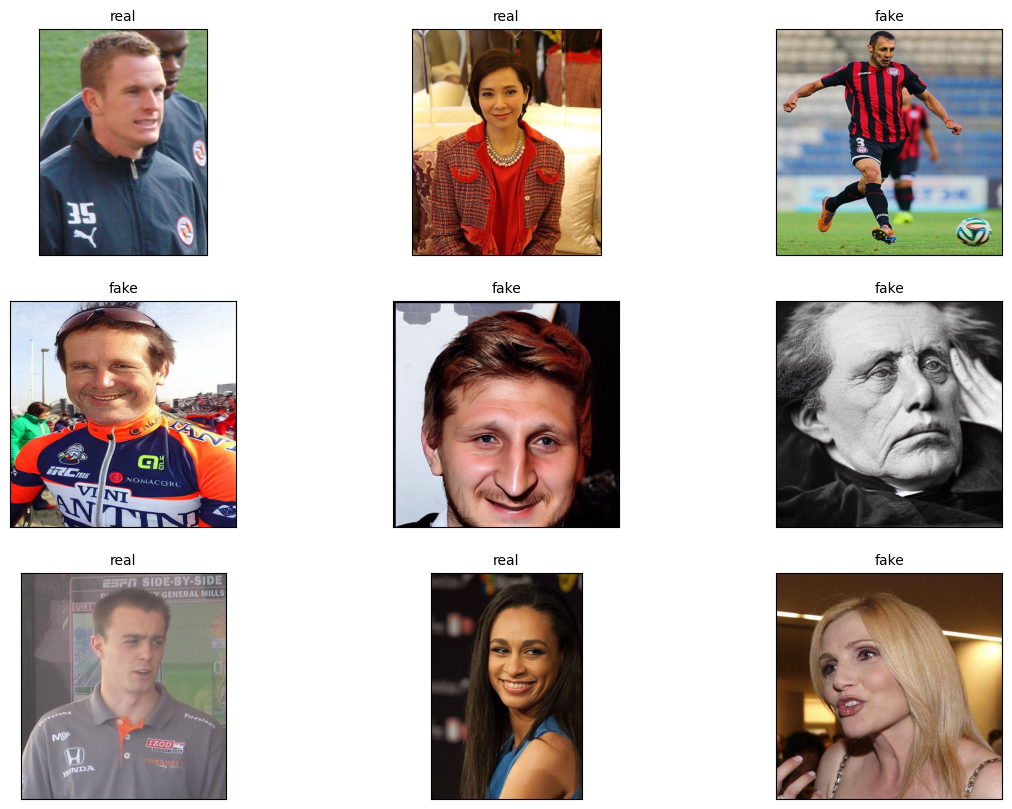

In [8]:
plt.figure(figsize = (14,10))
for i in range(9):
    random = np.random.randint(1,len(dataset))
    plt.subplot(3,3,i+1)
    plt.imshow(plt.imread(dataset.loc[random,"image_path"]))
    plt.title(dataset.loc[random, "img_status"], size = 10) 
    plt.xticks([])
    plt.yticks([])
    
plt.show()

In [9]:
# # Define transforms for grayscale images
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
#     transforms.ToTensor(),
#     transforms.Normalize([0.5], [0.5])  # Normalize grayscale images
# ])

# # Create normalized data directory if it doesn't exist
# os.makedirs(NORMALIZED_DATA, exist_ok=True)

# def preprocess_and_save_images():
#     total_images = len(dataset)
#     processed = 0
    
#     # Create subdirectories for real and fake images
#     real_dir = os.path.join(NORMALIZED_DATA, 'real')
#     fake_dir = os.path.join(NORMALIZED_DATA, 'fake')
#     os.makedirs(real_dir, exist_ok=True)
#     os.makedirs(fake_dir, exist_ok=True)
    
#     for idx, row in dataset.iterrows():
#         if idx % 1000 == 0:
#             print(f"Processing image {idx}/{total_images}")
        
#         try:
#             # Load image
#             img_path = row['image_path']
#             img = Image.open(img_path).convert('RGB')
            
#             # Apply transform
#             normalized_img = transform(img)
            
#             # Create filename from original path
#             filename = os.path.basename(img_path)
#             save_dir = real_dir if row['img_status'] == 'real' else fake_dir
#             save_path = os.path.join(save_dir, filename)
            
#             # Save as tensor
#             torch.save(normalized_img, save_path.replace('.jpg', '.pt'))
            
#             processed += 1
#         except Exception as e:
#             print(f"Error processing {img_path}: {e}")
    
#     print(f"Preprocessing complete. {processed}/{total_images} images processed successfully.")
    
# # Run preprocessing
# preprocess_and_save_images()

In [10]:
class DenseNetBinaryClassifier(nn.Module):
    def __init__(self):
        super(DenseNetBinaryClassifier, self).__init__()
        
        # 1. Base DenseNet121 model without classifier
        self.densenet = models.densenet121(weights=None)
        
        # 2. Modify first conv layer for grayscale input (1 channel)
        original_conv = self.densenet.features.conv0
        self.densenet.features.conv0 = nn.Conv2d(
            in_channels=1,  # grayscale
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=(original_conv.bias is not None)
        )
        
        # 3. Remove the original classifier
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()
        
        # 4. Add global average pooling (already part of DenseNet but we make it explicit)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 5. Add our custom classifier with sigmoid (equivalent to Dense(1, activation='sigmoid'))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_features, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        # Get features from DenseNet
        x = self.densenet.features(x)
        
        # Apply global pooling
        x = self.global_pool(x)
        
        # Apply classifier
        x = self.classifier(x)
        
        return x

In [11]:
# Create the model
model = DenseNetBinaryClassifier()

# Define loss function (binary_crossentropy equivalent)
criterion = nn.BCELoss()

# Define optimizer (Adam equivalent)
optimizer = torch.optim.Adam(model.parameters())

model = model.to(DEVICE)

# Print model summary
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

DenseNetBinaryClassifier(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1

In [12]:
# Create DataLoaders for both real and fake datasets
def load_dataset_from_tensors():
    # Paths for normalized data
    real_dir = os.path.join(NORMALIZED_DATA, 'real')
    fake_dir = os.path.join(NORMALIZED_DATA, 'fake')
    
    # Lists to store data and labels
    images = []
    labels = []
    
    # Load real images (label 1)
    print("Loading real images...")
    real_files = glob.glob(os.path.join(real_dir, '*.pt'))
    for idx, file_path in enumerate(real_files):
        if idx % 1000 == 0:
            print(f"Loading real image {idx}/{len(real_files)}")
        try:
            img_tensor = torch.load(file_path)
            images.append(img_tensor)
            labels.append(1.0)  # Real image = 1
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Load fake images (label 0)
    print("Loading fake images...")
    fake_files = glob.glob(os.path.join(fake_dir, '*.pt'))
    for idx, file_path in enumerate(fake_files):
        if idx % 1000 == 0:
            print(f"Loading fake image {idx}/{len(fake_files)}")
        try:
            img_tensor = torch.load(file_path)
            images.append(img_tensor)
            labels.append(0.0)  # Fake image = 0
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Convert lists to tensors
    X = torch.stack(images)
    y = torch.tensor(labels).float().view(-1, 1)
    
    print(f"Dataset loaded: {len(images)} images total ({len(real_files)} real, {len(fake_files)} fake)")
    
    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create TensorDatasets
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    return train_loader, test_loader

# Load the datasets
train_loader, test_loader = load_dataset_from_tensors()
# Print dataset information
train_batch = next(iter(train_loader))
print(f"Train batch shape: {train_batch[0].shape}, Label shape: {train_batch[1].shape}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Function to train the model
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10):
    best_accuracy = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 10)
        
        # Training loop
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        
        print(f"Training Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                # Statistics
                val_loss += loss.item() * inputs.size(0)
                predicted = (outputs > 0.5).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        epoch_val_loss = val_loss / len(test_loader.dataset)
        epoch_val_acc = val_correct / val_total
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Validation Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # Save best model
        if epoch_val_acc > best_accuracy:
            best_accuracy = epoch_val_acc
            torch.save(model.state_dict(), 'best_densenet_model.pth')
            print(f"Model saved with accuracy: {best_accuracy:.4f}")
        
        print()
    
    # Final evaluation metrics
    print("Final model evaluation:")
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    print(f"Accuracy: {metrics.accuracy_score(all_labels, all_preds):.4f}")
    print(f"Precision: {metrics.precision_score(all_labels, all_preds):.4f}")
    print(f"Recall: {metrics.recall_score(all_labels, all_preds):.4f}")
    print(f"F1 Score: {metrics.f1_score(all_labels, all_preds):.4f}")
    
    return model, history

Loading real images...
Loading real image 0/30000
Loading real image 1000/30000
Loading real image 2000/30000
Loading real image 3000/30000
Loading real image 4000/30000
Loading real image 5000/30000
Loading real image 6000/30000
Loading real image 7000/30000
Loading real image 8000/30000
Loading real image 9000/30000
Loading real image 10000/30000
Loading real image 11000/30000
Loading real image 12000/30000
Loading real image 13000/30000
Loading real image 14000/30000
Loading real image 15000/30000
Loading real image 16000/30000
Loading real image 17000/30000
Loading real image 18000/30000
Loading real image 19000/30000
Loading real image 20000/30000
Loading real image 21000/30000
Loading real image 22000/30000
Loading real image 23000/30000
Loading real image 24000/30000
Loading real image 25000/30000
Loading real image 26000/30000
Loading real image 27000/30000
Loading real image 28000/30000
Loading real image 29000/30000
Loading fake images...
Loading fake image 0/30000
Loading fa

Epoch 1/5
----------


Batch 0/750 - Loss: 0.6988
Batch 100/750 - Loss: 0.4235
Batch 200/750 - Loss: 0.3360
Batch 300/750 - Loss: 0.2621
Batch 400/750 - Loss: 0.2715
Batch 500/750 - Loss: 0.1488
Batch 600/750 - Loss: 0.1244
Batch 700/750 - Loss: 0.1925
Training Loss: 0.2462 Acc: 0.8978
Validation Loss: 0.2868 Acc: 0.8938
Model saved with accuracy: 0.8938

Epoch 2/5
----------
Batch 0/750 - Loss: 0.1194
Batch 100/750 - Loss: 0.1843
Batch 200/750 - Loss: 0.1516
Batch 300/750 - Loss: 0.1451
Batch 400/750 - Loss: 0.1247
Batch 500/750 - Loss: 0.2051
Batch 600/750 - Loss: 0.1753
Batch 700/750 - Loss: 0.1221
Training Loss: 0.1570 Acc: 0.9389
Validation Loss: 0.1591 Acc: 0.9371
Model saved with accuracy: 0.9371

Epoch 3/5
----------
Batch 0/750 - Loss: 0.2396
Batch 100/750 - Loss: 0.0874
Batch 200/750 - Loss: 0.1191
Batch 300/750 - Loss: 0.2618
Batch 400/750 - Loss: 0.0456
Batch 500/750 - Loss: 0.0882
Batch 600/750 - Loss: 0.0559
Batch 700/750 - Loss: 0.0887
Training Loss: 0.1294 Acc: 0.9491
Validation Loss: 0.1167 

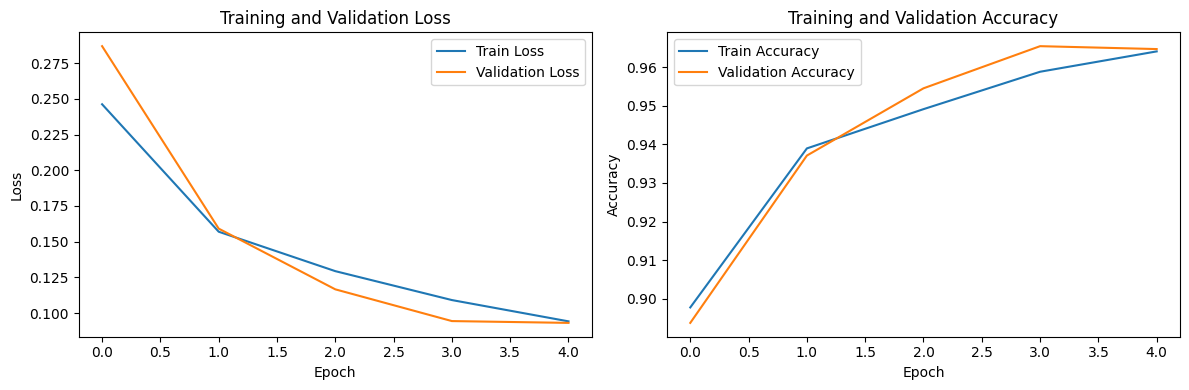

In [13]:
# Train the model
num_epochs = 5  # Adjust as needed
model, history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()